# Unsupervised Learning Trading Strategy

* Download/Load SP500 stocks prices data.
* Calculate different features and indicators on each stock.
* Aggregate on monthly level and filter top 150 most liquid stocks.
* Calculate Monthly Returns for different time-horizons.
* Download Fama-French Factors and Calculate Rolling Factor Betas.
* For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.
* For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization.
* Visualize Portfolio returns and compare to SP500 returns.

# All Packages Needed:
* pandas, numpy, matplotlib, statsmodels, pandas_datareader, datetime, yfinance, sklearn, PyPortfolioOpt

## 1. Download/Load SP500 stocks prices data.

In [4]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta_classic as pandas_ta
import warnings
warnings.filterwarnings('ignore')
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
response.raise_for_status()  

sp500 = pd.read_html(response.text)[0]

# sp500 = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
symbols_list = [symbol.replace('.', '-') for symbol in sp500['Symbol'].unique()]


end_date = '2023-09-27'

start_date = pd.to_datetime(end_date)-pd.DateOffset(365*8)

df = yf.download(tickers=symbols_list,
                 start=start_date,
                 end=end_date, auto_adjust=False).stack()

df.index.names = ['date', 'ticker']

df.columns = df.columns.str.lower()

df

[*********************100%***********************]  503 of 503 completed

5 Failed downloads:
['SOLV', 'Q', 'VLTO', 'GEV', 'SOLS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2015-09-29 00:00:00 -> 2023-09-27) (Yahoo error = "Data doesn\'t exist for startDate = 1443499200, endDate = 1695787200")')


Price               adj close       close        high         low        open  \
date       ticker                                                               
2015-09-29 A        31.122843   33.740002   34.060001   33.240002   33.360001   
           AAPL     24.508566   27.264999   28.377501   26.965000   28.207500   
           ABBV     34.512173   52.790001   54.189999   51.880001   53.099998   
           ABT      32.529427   39.500000   40.150002   39.029999   39.259998   
           ACGL     23.217773   24.416668   24.456667   24.100000   24.170000   
...                       ...         ...         ...         ...         ...   
2023-09-26 XYZ      44.810001   44.810001   45.740002   44.560001   44.939999   
           YUM     119.281685  124.010002  124.739998  123.449997  124.239998   
           ZBH     110.243698  112.459999  117.110001  112.419998  116.769997   
           ZBRA    223.960007  223.960007  226.649994  222.580002  225.970001   
           ZTS     172.425781  176.869995  178.449997  176.270004  176.580002   

Price                   volume  
date       ticker               
2015-09-29 A         2252400.0  
           AAPL    293461600.0  
           ABBV     12842800.0  
           ABT      12287500.0  
           ACGL      1888800.0  
...                        ...  
2023-09-26 XYZ      10168200.0  
           YUM       1500600.0  
           ZBH       3610500.0  
           ZBRA       355400.0  
           ZTS       1463200.0  

[974259 rows x 6 columns]

## 2. Calculate features and technical indicators for each stock.

* Garman-Klass Volatility
* RSI
* Bollinger Bands
* ATR
* MACD
* Dollar Volume

\begin{equation}
\text{Garman-Klass Volatility} = \frac{(\ln(\text{High}) - \ln(\text{Low}))^2}{2} - (2\ln(2) - 1)(\ln(\text{Adj Close}) - \ln(\text{Open}))^2
\end{equation}

In [5]:
df['garman_klass_vol'] = ((np.log(df['high'])-np.log(df['low']))**2)/2-(2*np.log(2)-1)*((np.log(df['adj close'])-np.log(df['open']))**2)

df['rsi'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.rsi(close=x, length=20))

df['bb_low'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,0])
                                                          
df['bb_mid'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,1])
                                                          
df['bb_high'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log1p(x), length=20).iloc[:,2])

def compute_atr(stock_data):
    atr = pandas_ta.atr(high=stock_data['high'],
                        low=stock_data['low'],
                        close=stock_data['close'],
                        length=14)
    return atr.sub(atr.mean()).div(atr.std())

df['atr'] = df.groupby(level=1, group_keys=False).apply(compute_atr)

def compute_macd(close):
    macd = pandas_ta.macd(close=close, length=20).iloc[:,0]
    return macd.sub(macd.mean()).div(macd.std())

df['macd'] = df.groupby(level=1, group_keys=False)['adj close'].apply(compute_macd)

df['dollar_volume'] = (df['adj close']*df['volume'])/1e6

df

Price               adj close       close        high         low        open  \
date       ticker                                                               
2015-09-29 A        31.122843   33.740002   34.060001   33.240002   33.360001   
           AAPL     24.508566   27.264999   28.377501   26.965000   28.207500   
           ABBV     34.512173   52.790001   54.189999   51.880001   53.099998   
           ABT      32.529427   39.500000   40.150002   39.029999   39.259998   
           ACGL     23.217773   24.416668   24.456667   24.100000   24.170000   
...                       ...         ...         ...         ...         ...   
2023-09-26 XYZ      44.810001   44.810001   45.740002   44.560001   44.939999   
           YUM     119.281685  124.010002  124.739998  123.449997  124.239998   
           ZBH     110.243698  112.459999  117.110001  112.419998  116.769997   
           ZBRA    223.960007  223.960007  226.649994  222.580002  225.970001   
           ZTS     172.425781  176.869995  178.449997  176.270004  176.580002   

Price                   volume  garman_klass_vol        rsi    bb_low  \
date       ticker                                                       
2015-09-29 A         2252400.0         -0.001564        NaN       NaN   
           AAPL    293461600.0         -0.006329        NaN       NaN   
           ABBV     12842800.0         -0.070765        NaN       NaN   
           ABT      12287500.0         -0.013262        NaN       NaN   
           ACGL      1888800.0         -0.000516        NaN       NaN   
...                        ...               ...        ...       ...   
2023-09-26 XYZ      10168200.0          0.000338  25.939817  3.799574   
           YUM       1500600.0         -0.000587  36.057184  4.787645   
           ZBH       3610500.0         -0.000443  31.893246  4.734343   
           ZBRA       355400.0          0.000133  29.494977  5.400991   
           ZTS       1463200.0         -0.000143  42.623489  5.138268   

Price                bb_mid   bb_high       atr      macd  dollar_volume  
date       ticker                                                         
2015-09-29 A            NaN       NaN       NaN       NaN      70.101091  
           AAPL         NaN       NaN       NaN       NaN    7192.322964  
           ABBV         NaN       NaN       NaN       NaN     443.232932  
           ABT          NaN       NaN       NaN       NaN     399.705329  
           ACGL         NaN       NaN       NaN       NaN      43.853730  
...                     ...       ...       ...       ...            ...  
2023-09-26 XYZ     3.980555  4.161536 -0.637443 -0.990293     455.637056  
           YUM     4.817605  4.847564  0.142547 -1.363695     178.994096  
           ZBH     4.774005  4.813668 -0.381708 -0.881067     398.034872  
           ZBRA    5.539167  5.677342 -0.057389 -1.600791      79.595386  
           ZTS     5.197076  5.255883  0.651515 -1.188277     252.293403  

[974259 rows x 14 columns]

## 3. Aggregate to monthly level and filter top 150 most liquid stocks for each month.

* To reduce training time and experiment with features and strategies, we convert the business-daily data to month-end frequency.

In [6]:
last_cols = [c for c in df.columns.unique(0) if c not in ['dollar_volume', 'volume', 'open',
                                                          'high', 'low', 'close']]

data = (pd.concat([df.unstack('ticker')['dollar_volume'].resample('M').mean().stack('ticker').to_frame('dollar_volume'),
                   df.unstack()[last_cols].resample('M').last().stack('ticker')],
                  axis=1)).dropna()

data

dollar_volume   adj close  garman_klass_vol        rsi  \
date       ticker                                                           
2015-11-30 A          134.434706   38.576065         -0.002691  73.421439   
           AAPL      4000.712145   26.698828         -0.003741  55.537318   
           ABBV       320.630210   38.367222         -0.076278  49.376919   
           ABT        205.657582   37.207779         -0.015338  56.962565   
           ACGL        28.174423   22.970539         -0.001121  35.682522   
...                          ...         ...               ...        ...   
2023-09-30 APP        121.348834   38.590000          0.000732  51.250235   
           HOOD        63.043789    9.530000          0.000396  32.454969   
           CEG        195.128961  107.016655         -0.000103  55.245474   
           GEHC       211.739365   65.962318          0.000181  40.922287   
           KVUE       640.357019   19.098038         -0.002025  35.706330   

                     bb_low    bb_mid   bb_high       atr      macd  
date       ticker                                                    
2015-11-30 A       3.534802  3.607227  3.679653 -1.033887  0.567156  
           AAPL    3.276097  3.319400  3.362702 -0.967900 -0.142789  
           ABBV    3.676498  3.724687  3.772877 -0.526809  0.145678  
           ABT     3.628045  3.649882  3.671720 -1.064842  0.335557  
           ACGL    3.177974  3.195190  3.212406 -1.155694 -0.550166  
...                     ...       ...       ...       ...       ...  
2023-09-30 APP     3.653485  3.744206  3.834927 -0.685843  0.205403  
           HOOD    2.361184  2.444530  2.527875 -0.682699  0.204651  
           CEG     4.644354  4.684524  4.724694 -0.436215  0.366876  
           GEHC    4.152934  4.210467  4.268001 -0.893478 -1.116463  
           KVUE    2.970144  3.044930  3.119715 -0.899746 -1.435622  

[46001 rows x 9 columns]

* Calculate 5-year rolling average of dollar volume for each stocks before filtering.

In [7]:
data['dollar_volume'] = (data.loc[:, 'dollar_volume'].unstack('ticker').rolling(5*12, min_periods=12).mean().stack())

data['dollar_vol_rank'] = (data.groupby('date')['dollar_volume'].rank(ascending=False))

data = data[data['dollar_vol_rank']<150].drop(['dollar_volume', 'dollar_vol_rank'], axis=1)

data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2016-10-31 AAPL     26.060883         -0.002842  49.891120  3.288653   
           ABBV     38.226246         -0.061596  27.477799  3.703217   
           ABT      33.321083         -0.010913  38.008859  3.526701   
           ACN     101.253738         -0.006765  53.823582  4.614949   
           ADBE    107.510002          0.000059  53.668389  4.679513   
...                       ...               ...        ...       ...   
2023-09-30 DDOG     86.570000          0.000314  37.040091  4.476874   
           PLTR     13.960000          0.000214  41.544692  2.701939   
           DASH     74.580002          0.000326  36.955365  4.329191   
           ABNB    132.279999          0.000213  44.494127  4.857047   
           COIN     70.519997          0.001007  39.839731  4.273572   

                     bb_mid   bb_high       atr      macd  
date       ticker                                          
2016-10-31 AAPL    3.317526  3.346400 -1.038688 -0.195978  
           ABBV    3.757316  3.811415 -0.893132 -0.760594  
           ABT     3.577135  3.627569 -1.035224 -0.650888  
           ACN     4.626584  4.638219 -0.996806 -0.135457  
           ADBE    4.694639  4.709766 -1.230331 -0.109039  
...                     ...       ...       ...       ...  
2023-09-30 DDOG    4.560278  4.643681 -0.867969 -0.699392  
           PLTR    2.779743  2.857548 -0.426167 -0.433581  
           DASH    4.403906  4.478620 -1.145418 -0.117919  
           ABNB    4.940924  5.024801 -1.006939 -0.037854  
           COIN    4.378785  4.483998 -1.183735  0.049978  

[12516 rows x 8 columns]

## 4. Calculate Monthly Returns for different time horizons as features.

* To capture time series dynamics that reflect, for example, momentum patterns, we compute historical returns using the method .pct_change(lag), that is, returns over various monthly periods as identified by lags.

In [8]:
def calculate_returns(df):

    outlier_cutoff = 0.005

    lags = [1, 2, 3, 6, 9, 12]

    for lag in lags:

        df[f'return_{lag}m'] = (df['adj close']
                              .pct_change(lag)
                              .pipe(lambda x: x.clip(lower=x.quantile(outlier_cutoff),
                                                     upper=x.quantile(1-outlier_cutoff)))
                              .add(1)
                              .pow(1/lag)
                              .sub(1))
    return df
    
    
data = data.groupby(level=1, group_keys=False).apply(calculate_returns).dropna()

data

adj close  garman_klass_vol        rsi    bb_low  \
date       ticker                                                      
2017-10-31 AAPL     39.484222         -0.001316  69.196736  3.589090   
           ABBV     64.105499         -0.046862  55.247897  4.146029   
           ABT      47.118374         -0.008097  53.844879  3.864398   
           ACN     126.506264         -0.005890  69.365142  4.780248   
           ADBE    175.160004          0.000067  70.089317  4.951759   
...                       ...               ...        ...       ...   
2023-09-30 DDOG     86.570000          0.000314  37.040091  4.476874   
           PLTR     13.960000          0.000214  41.544692  2.701939   
           DASH     74.580002          0.000326  36.955365  4.329191   
           ABNB    132.279999          0.000213  44.494127  4.857047   
           COIN     70.519997          0.001007  39.839731  4.273572   

                     bb_mid   bb_high       atr      macd  return_1m  \
date       ticker                                                      
2017-10-31 AAPL    3.635955  3.682820 -0.906642 -0.039275   0.096808   
           ABBV    4.192355  4.238681  0.375557  0.473816   0.022728   
           ABT     3.887954  3.911510 -1.040044  0.276133   0.021276   
           ACN     4.819920  4.859593 -0.986514  0.352342   0.064180   
           ADBE    5.089292  5.226825 -0.888269  0.612102   0.174152   
...                     ...       ...       ...       ...        ...   
2023-09-30 DDOG    4.560278  4.643681 -0.867969 -0.699392  -0.102716   
           PLTR    2.779743  2.857548 -0.426167 -0.433581  -0.068091   
           DASH    4.403906  4.478620 -1.145418 -0.117919  -0.113515   
           ABNB    4.940924  5.024801 -1.006939 -0.037854   0.005549   
           COIN    4.378785  4.483998 -1.183735  0.049978  -0.114070   

                   return_2m  return_3m  return_6m  return_9m  return_12m  
date       ticker                                                          
2017-10-31 AAPL     0.015250   0.044955   0.028875   0.038941    0.035228  
           ABBV     0.098590   0.091379   0.056495   0.047273    0.044026  
           ABT      0.034308   0.034801   0.038672   0.031320    0.029294  
           ACN      0.048454   0.037203   0.028692   0.027398    0.018728  
           ADBE     0.062497   0.061392   0.045993   0.049515    0.041515  
...                      ...        ...        ...        ...         ...  
2023-09-30 DDOG    -0.138786  -0.041732   0.029624   0.018352   -0.002098  
           PLTR    -0.161174  -0.030723   0.087272   0.090143    0.046083  
           DASH    -0.093658  -0.008091   0.027006   0.048207    0.034568  
           ABNB    -0.067704   0.010603   0.010289   0.049124    0.019401  
           COIN    -0.154340  -0.004822   0.007147   0.079010    0.007477  

[10332 rows x 14 columns]

## 5. Download Fama-French Factors and Calculate Rolling Factor Betas.

* We will introduce the Fama—French data to estimate the exposure of assets to common risk factors using linear regression.

* The five Fama—French factors, namely market risk, size, value, operating profitability, and investment have been shown empirically to explain asset returns and are commonly used to assess the risk/return profile of portfolios. Hence, it is natural to include past factor exposures as financial features in models.

* We can access the historical factor returns using the pandas-datareader and estimate historical exposures using the RollingOLS rolling linear regression.

In [9]:
factor_data = web.DataReader('F-F_Research_Data_5_Factors_2x3',
                               'famafrench',
                               start='2010')[0].drop('RF', axis=1)

factor_data.index = factor_data.index.to_timestamp()

factor_data = factor_data.resample('M').last().div(100)

factor_data.index.name = 'date'

factor_data = factor_data.join(data['return_1m']).sort_index()

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2017-10-31 AAPL    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.096808
           ABBV    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.022728
           ABT     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.021276
           ACN     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.064180
           ADBE    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.174152
...                   ...     ...     ...     ...     ...        ...
2023-09-30 WDAY   -0.0523 -0.0178  0.0149  0.0188 -0.0077  -0.062413
           WFC    -0.0523 -0.0178  0.0149  0.0188 -0.0077  -0.015500
           WMT    -0.0523 -0.0178  0.0149  0.0188 -0.0077  -0.000677
           XOM    -0.0523 -0.0178  0.0149  0.0188 -0.0077   0.046947
           XYZ    -0.0523 -0.0178  0.0149  0.0188 -0.0077  -0.222723

[10332 rows x 6 columns]

* Filter out stocks with less than 10 months of data.

In [10]:
observations = factor_data.groupby(level=1).size()

valid_stocks = observations[observations >= 10]

factor_data = factor_data[factor_data.index.get_level_values('ticker').isin(valid_stocks.index)]

factor_data

Mkt-RF     SMB     HML     RMW     CMA  return_1m
date       ticker                                                   
2017-10-31 AAPL    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.096808
           ABBV    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.022728
           ABT     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.021276
           ACN     0.0225 -0.0191  0.0013  0.0092 -0.0314   0.064180
           ADBE    0.0225 -0.0191  0.0013  0.0092 -0.0314   0.174152
...                   ...     ...     ...     ...     ...        ...
2023-09-30 WDAY   -0.0523 -0.0178  0.0149  0.0188 -0.0077  -0.062413
           WFC    -0.0523 -0.0178  0.0149  0.0188 -0.0077  -0.015500
           WMT    -0.0523 -0.0178  0.0149  0.0188 -0.0077  -0.000677
           XOM    -0.0523 -0.0178  0.0149  0.0188 -0.0077   0.046947
           XYZ    -0.0523 -0.0178  0.0149  0.0188 -0.0077  -0.222723

[10313 rows x 6 columns]

* Calculate Rolling Factor Betas.

In [11]:
betas = (factor_data.groupby(level=1,
                            group_keys=False)
         .apply(lambda x: RollingOLS(endog=x['return_1m'], 
                                     exog=sm.add_constant(x.drop('return_1m', axis=1)),
                                     window=min(24, x.shape[0]),
                                     min_nobs=len(x.columns)+1)
         .fit(params_only=True)
         .params
         .drop('const', axis=1)))

betas 

Mkt-RF       SMB       HML       RMW       CMA
date       ticker                                                  
2017-10-31 AAPL         NaN       NaN       NaN       NaN       NaN
           ABBV         NaN       NaN       NaN       NaN       NaN
           ABT          NaN       NaN       NaN       NaN       NaN
           ACN          NaN       NaN       NaN       NaN       NaN
           ADBE         NaN       NaN       NaN       NaN       NaN
...                     ...       ...       ...       ...       ...
2023-09-30 WDAY    1.080997 -0.944552 -0.562809 -0.905698 -0.246555
           WFC     1.121962  0.241155  2.053292 -0.498174 -1.545369
           WMT     0.703760 -0.314502 -0.404436 -0.144512  0.500036
           XOM     0.983110 -1.132610  1.727676 -0.686519 -0.356412
           XYZ     2.417982  1.928899 -0.345458 -1.677475  0.481122

[10313 rows x 5 columns]

* Join the rolling factors data to the main features dataframe.

In [12]:
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

data = (data.join(betas.groupby('ticker').shift()))

data.loc[:, factors] = data.groupby('ticker', group_keys=False)[factors].apply(lambda x: x.fillna(x.mean()))

data = data.drop('adj close', axis=1)

data = data.dropna()

data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 10084 entries, (Timestamp('2017-10-31 00:00:00'), 'AAPL') to (Timestamp('2023-09-30 00:00:00'), 'DDOG')
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   garman_klass_vol  10084 non-null  float64
 1   rsi               10084 non-null  float64
 2   bb_low            10084 non-null  float64
 3   bb_mid            10084 non-null  float64
 4   bb_high           10084 non-null  float64
 5   atr               10084 non-null  float64
 6   macd              10084 non-null  float64
 7   return_1m         10084 non-null  float64
 8   return_2m         10084 non-null  float64
 9   return_3m         10084 non-null  float64
 10  return_6m         10084 non-null  float64
 11  return_9m         10084 non-null  float64
 12  return_12m        10084 non-null  float64
 13  Mkt-RF            10084 non-null  float64
 14  SMB               10084 non-null  float64
 15  HML      

### At this point we have to decide on what ML model and approach to use for predictions etc.


## 6. For each month fit a K-Means Clustering Algorithm to group similar assets based on their features.

### K-Means Clustering


In [21]:
target_rsi_values = [30, 45, 55, 70]

initial_centroids = np.zeros((len(target_rsi_values), 18))

initial_centroids[:, 6] = target_rsi_values

initial_centroids

array([[ 0.,  0.,  0.,  0.,  0.,  0., 30.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 45.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 55.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., 70.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.]])

In [22]:
from sklearn.cluster import KMeans

# data = data.drop('cluster', axis=1)

def get_clusters(df):
    df['cluster'] = KMeans(n_clusters=4,
                           random_state=0,
                           init=initial_centroids).fit(df).labels_
    return df

data = data.dropna().groupby('date', group_keys=False).apply(get_clusters)

data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2017-10-31 AAPL           -0.001316  69.196736  3.589090  3.635955  3.682820   
           ABBV           -0.046862  55.247897  4.146029  4.192355  4.238681   
           ABT            -0.008097  53.844879  3.864398  3.887954  3.911510   
           ACN            -0.005890  69.365142  4.780248  4.819920  4.859593   
           ADBE            0.000067  70.089317  4.951759  5.089292  5.226825   
...                             ...        ...       ...       ...       ...   
2023-09-30 XYZ             0.000338  25.939817  3.799574  3.980555  4.161536   
           MRNA            0.000146  38.747314  4.582514  4.685332  4.788149   
           UBER            0.000441  45.005268  3.806654  3.862227  3.917801   
           CRWD            0.000144  51.534803  5.026187  5.103696  5.181204   
           DDOG            0.000314  37.040091  4.476874  4.560278  4.643681   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2017-10-31 AAPL   -0.906642 -0.039275   0.096808   0.015250   0.044955   
           ABBV    0.375557  0.473816   0.022728   0.098590   0.091379   
           ABT    -1.040044  0.276133   0.021276   0.034308   0.034801   
           ACN    -0.986514  0.352342   0.064180   0.048454   0.037203   
           ADBE   -0.888269  0.612102   0.174152   0.062497   0.061392   
...                     ...       ...        ...        ...        ...   
2023-09-30 XYZ    -0.637443 -0.990293  -0.222723  -0.247423  -0.123607   
           MRNA   -0.529511 -0.376899  -0.132219  -0.086803  -0.068763   
           UBER   -0.746098 -0.133973  -0.062672  -0.053920   0.008422   
           CRWD   -0.744862  0.245950  -0.015641  -0.003656   0.029981   
           DDOG   -0.867969 -0.699392  -0.102716  -0.138786  -0.041732   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2017-10-31 AAPL     0.028875   0.038941    0.035228  1.276518 -0.251058   
           ABBV     0.056495   0.047273    0.044026  0.505467  0.360797   
           ABT      0.038672   0.031320    0.029294  0.833399 -0.194859   
           ACN      0.028692   0.027398    0.018728  1.203790 -0.154550   
           ADBE     0.045993   0.049515    0.041515  1.109875 -0.318485   
...                      ...        ...         ...       ...       ...   
2023-09-30 XYZ     -0.068630  -0.036876   -0.016915  2.425948  1.930575   
           MRNA    -0.071952  -0.064976   -0.015431  1.153388  0.829705   
           UBER     0.057244   0.066838    0.043691  1.089340  1.123991   
           CRWD     0.026391   0.047942   -0.002216  0.596185 -0.982421   
           DDOG     0.029624   0.018352   -0.002098  0.598156  1.152212   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2017-10-31 AAPL   -0.610539  0.680839  0.488806        2  
           ABBV   -0.030546  0.178882  0.188314        3  
           ABT    -0.528604  0.255533  0.985906        3  
           ACN    -0.339715  0.270245  0.196927        2  
           ADBE   -0.184536 -0.218400 -0.687454        2  
...                     ...       ...       ...      ...  
2023-09-30 XYZ    -0.378994 -1.637181  0.502943        0  
           MRNA   -1.184729  0.621376  1.032699        3  
           UBER   -0.230036 -1.532496 -0.493454        3  
           CRWD   -0.701008 -2.504568 -0.808184        2  
           DDOG   -0.670440 -0.681060 -0.694730        3  

[10084 rows x 19 columns]

In [23]:
def plot_clusters(data):

    cluster_0 = data[data['cluster']==0]
    cluster_1 = data[data['cluster']==1]
    cluster_2 = data[data['cluster']==2]
    cluster_3 = data[data['cluster']==3]

    plt.scatter(cluster_0.iloc[:,0] , cluster_0.iloc[:,6] , color = 'red', label='cluster 0')
    plt.scatter(cluster_1.iloc[:,0] , cluster_1.iloc[:,6] , color = 'green', label='cluster 1')
    plt.scatter(cluster_2.iloc[:,0] , cluster_2.iloc[:,6] , color = 'blue', label='cluster 2')
    plt.scatter(cluster_3.iloc[:,0] , cluster_3.iloc[:,6] , color = 'black', label='cluster 3')
    
    plt.legend()
    plt.show()
    return


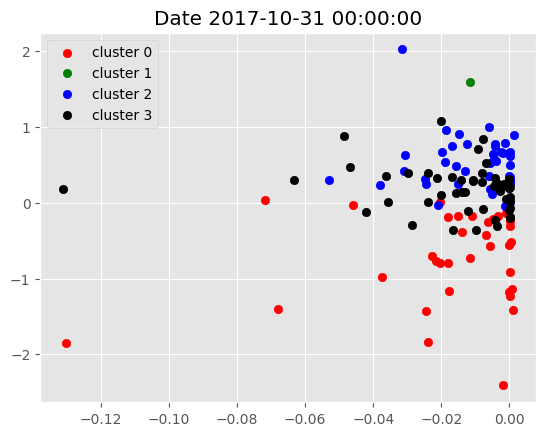

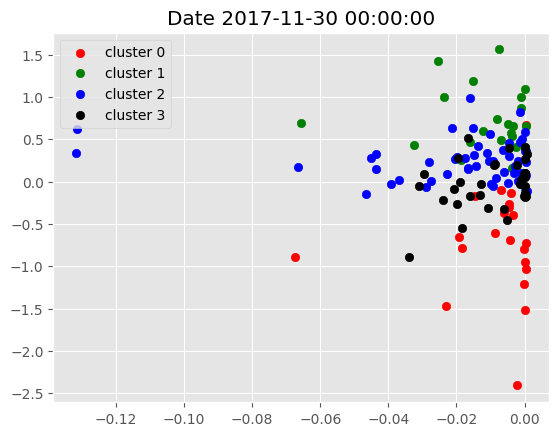

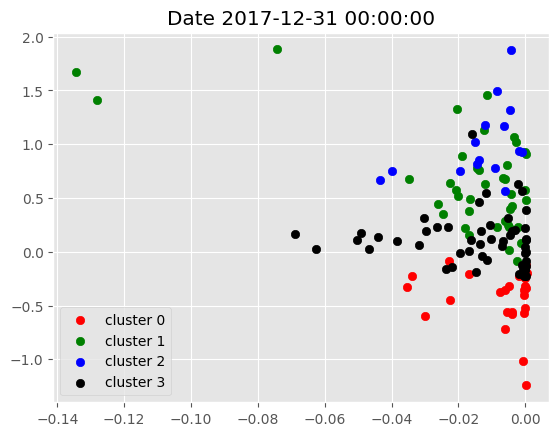

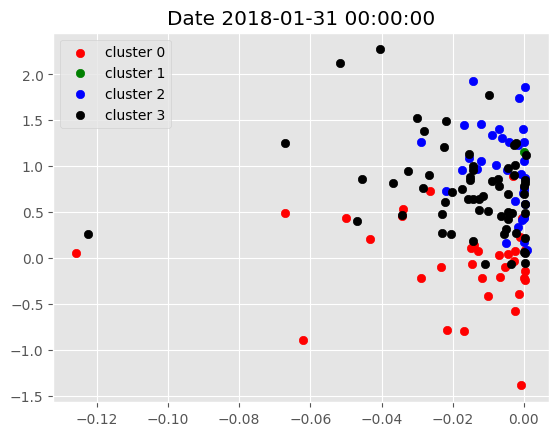

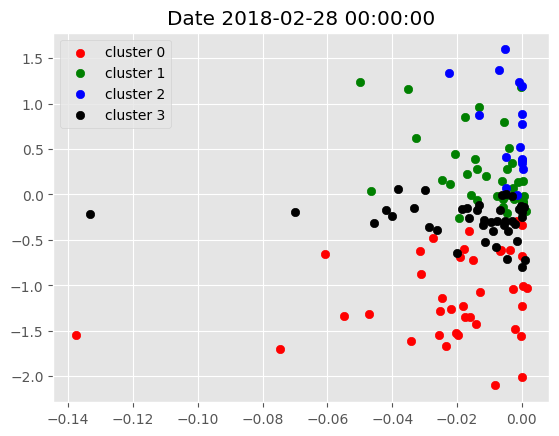

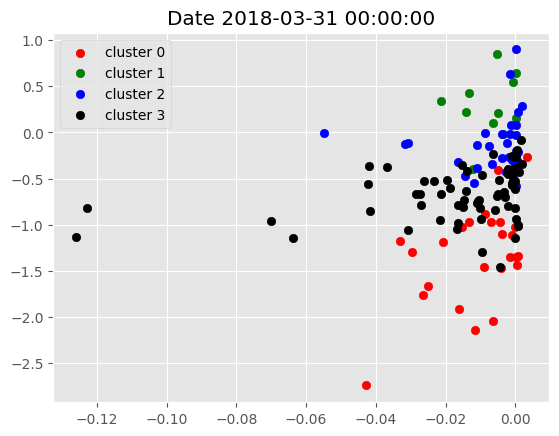

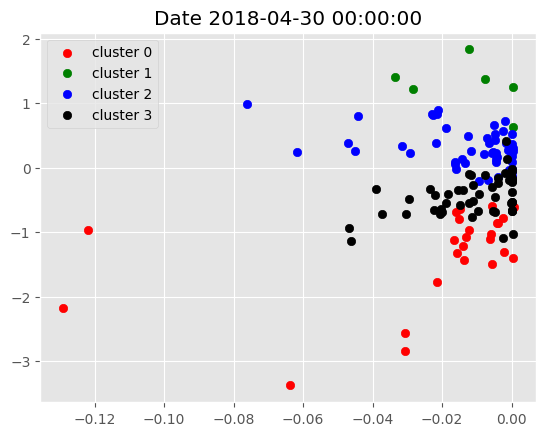

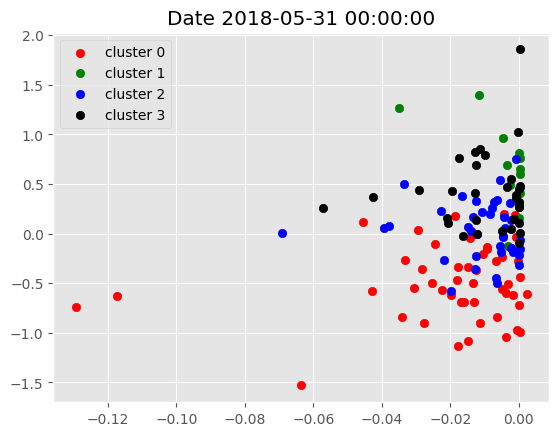

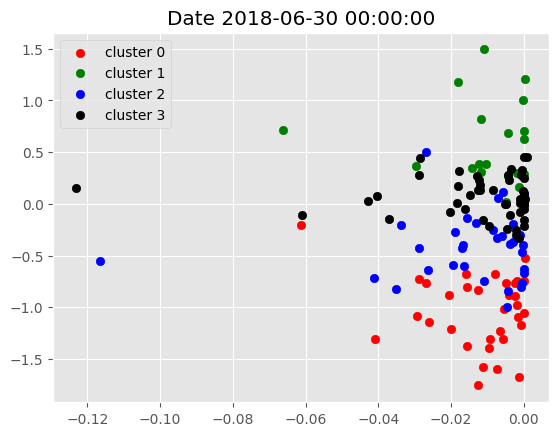

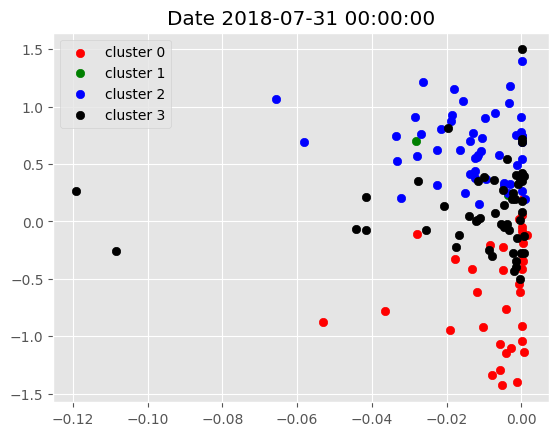

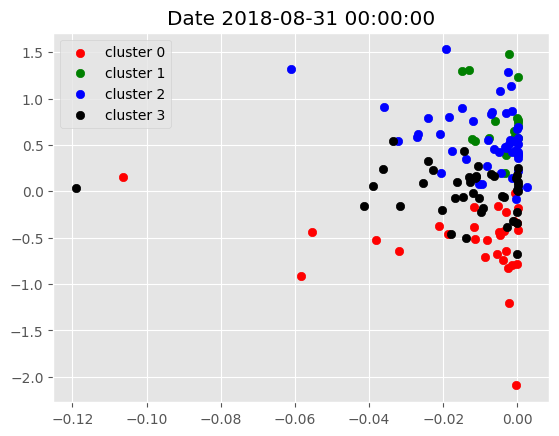

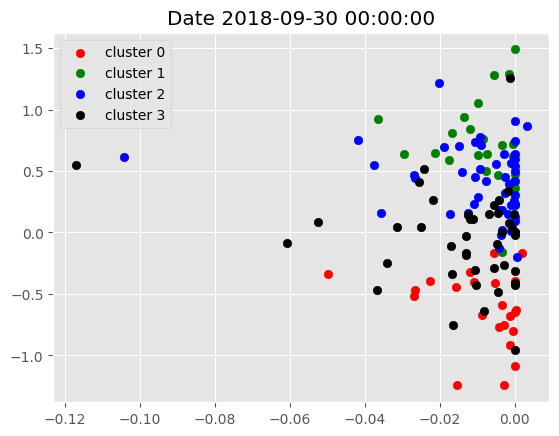

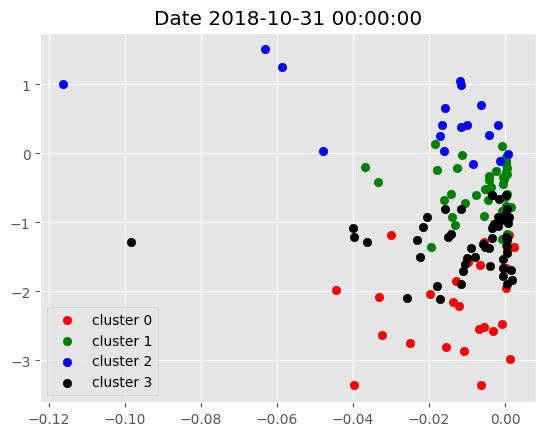

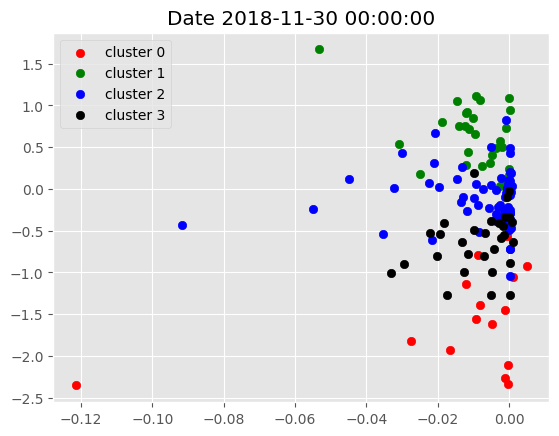

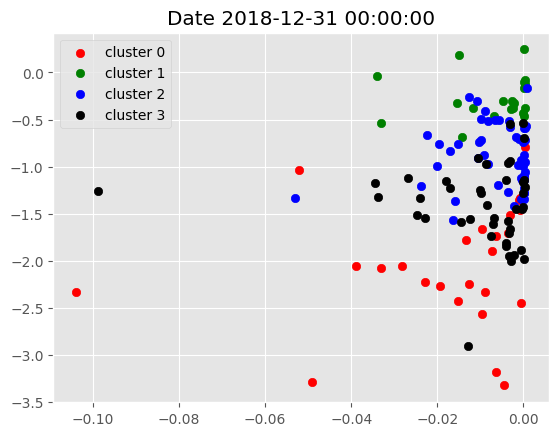

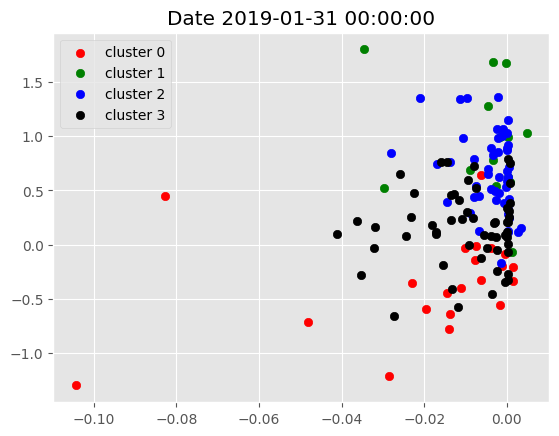

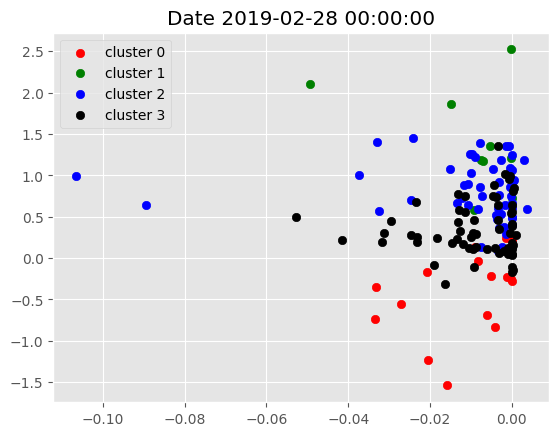

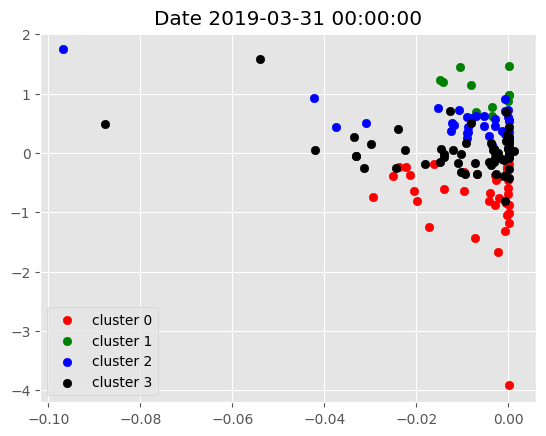

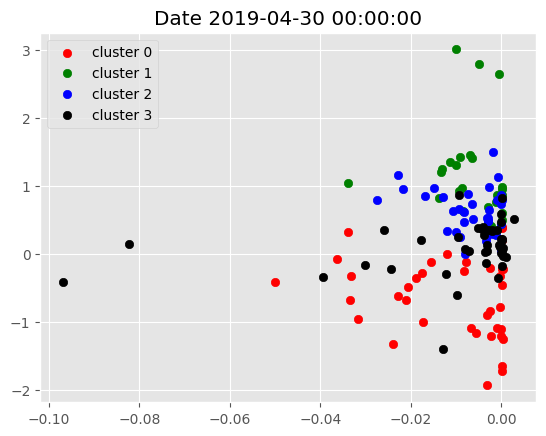

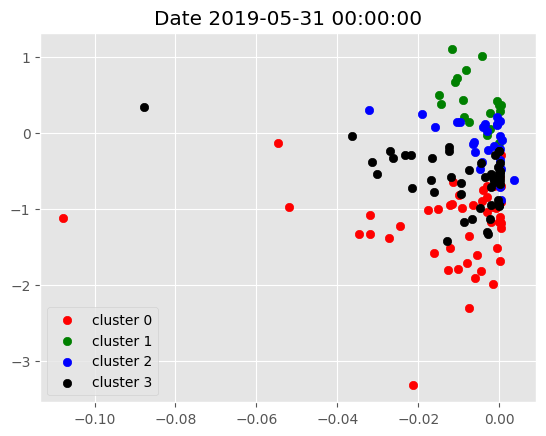

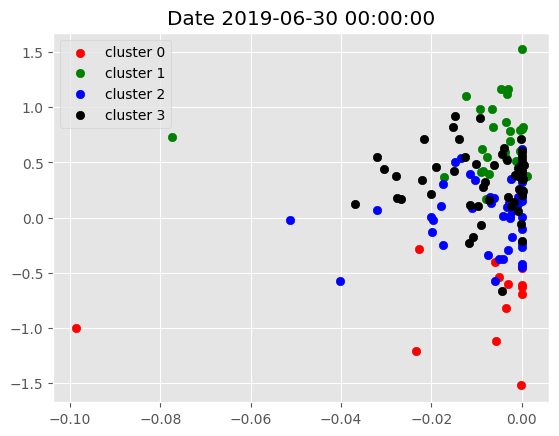

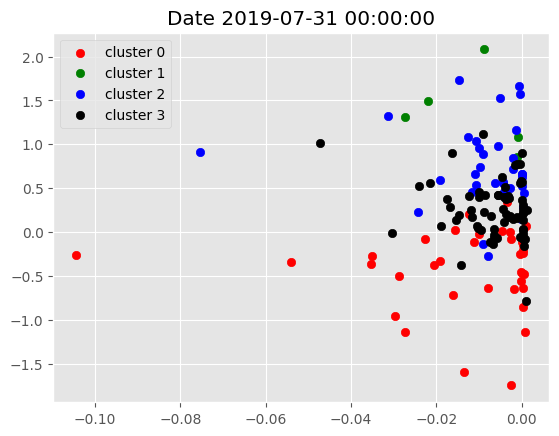

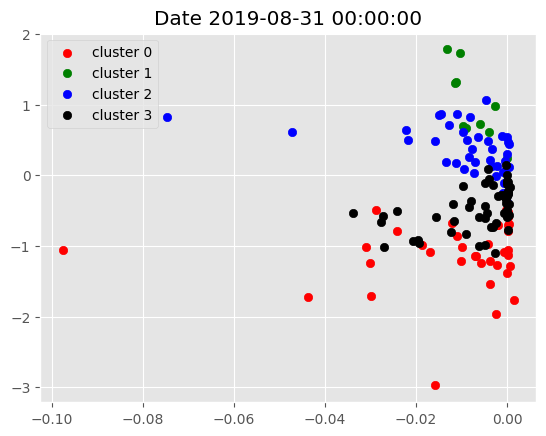

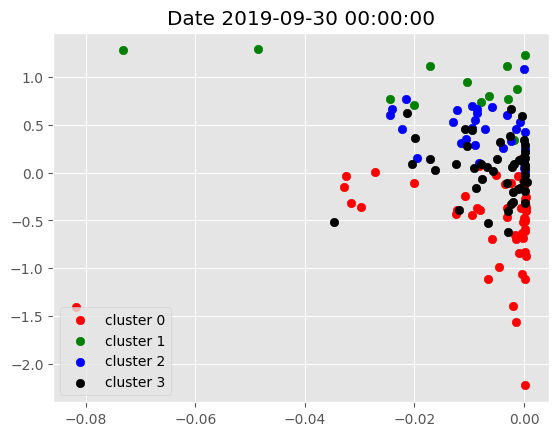

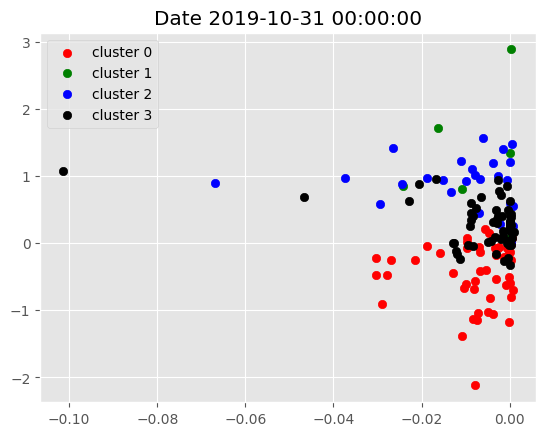

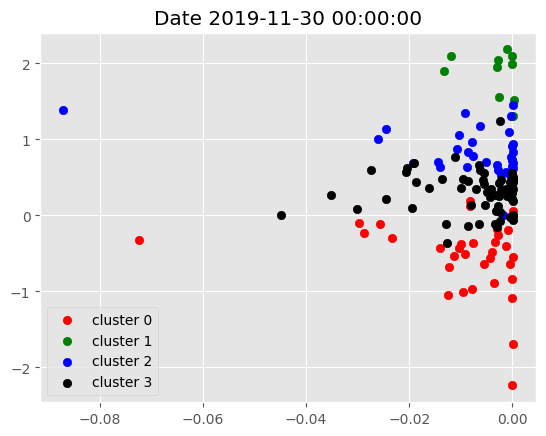

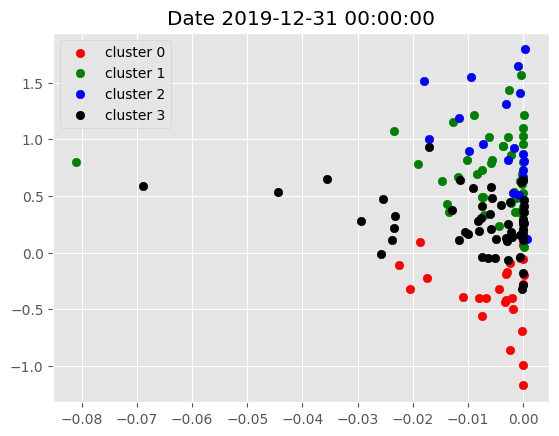

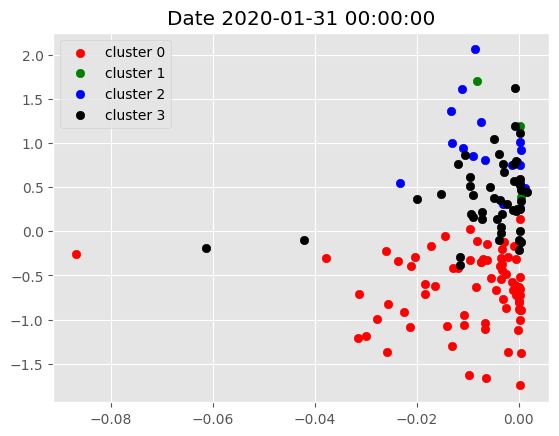

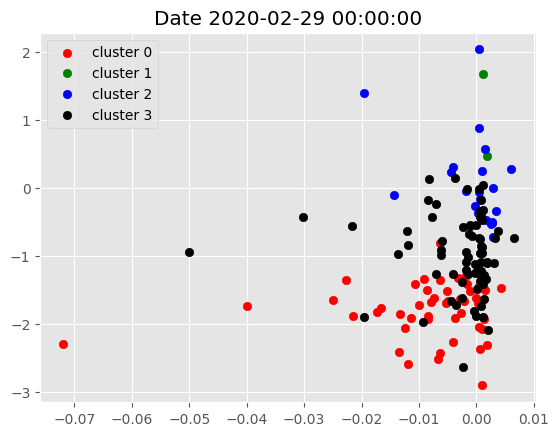

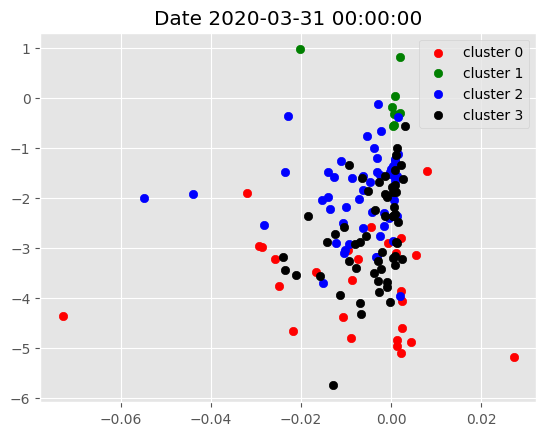

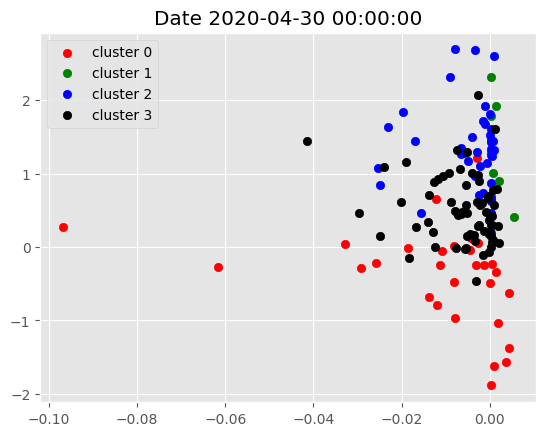

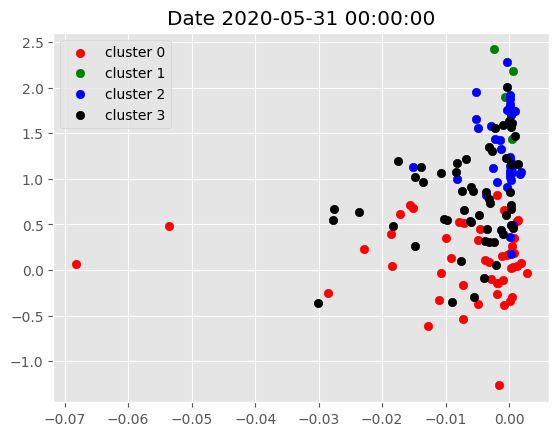

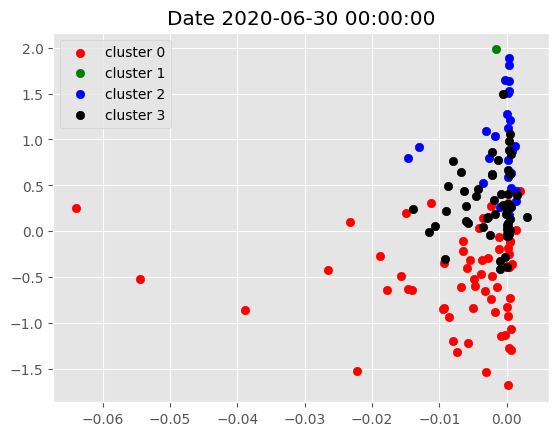

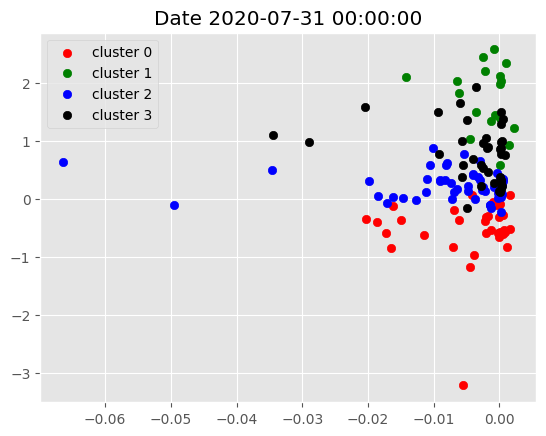

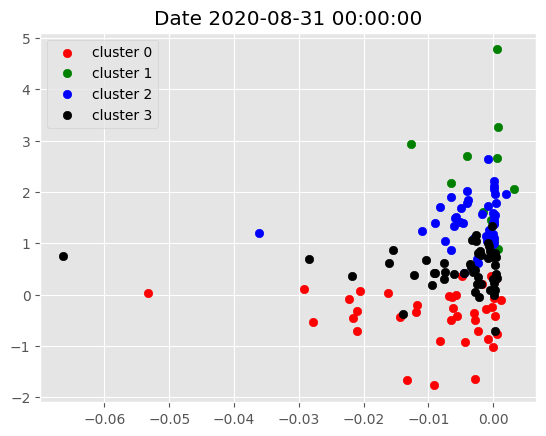

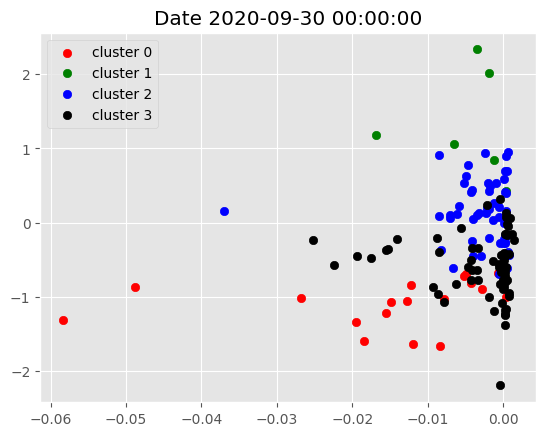

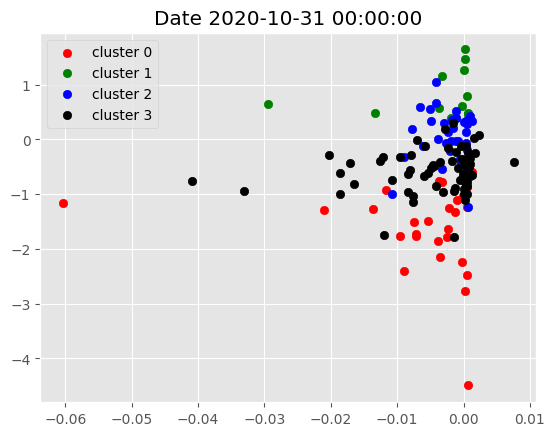

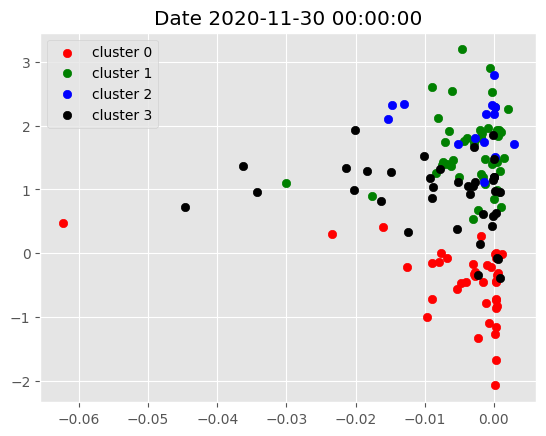

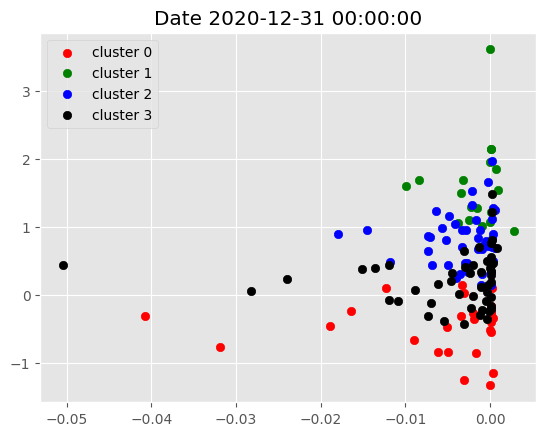

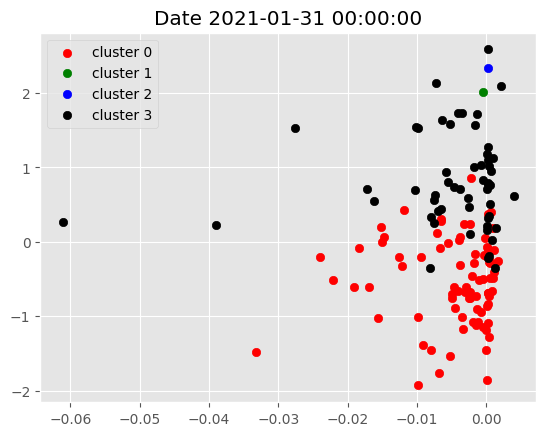

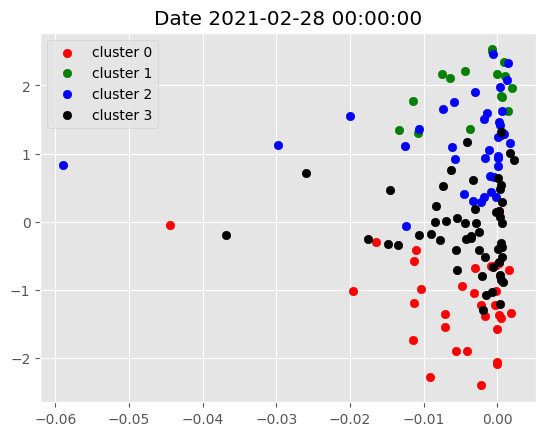

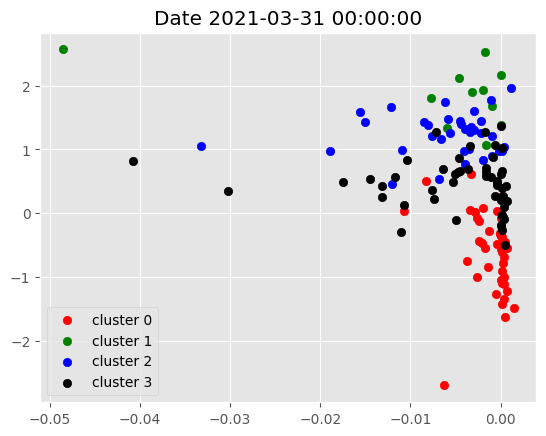

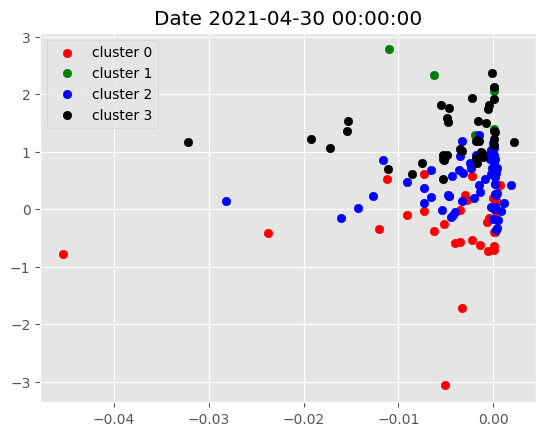

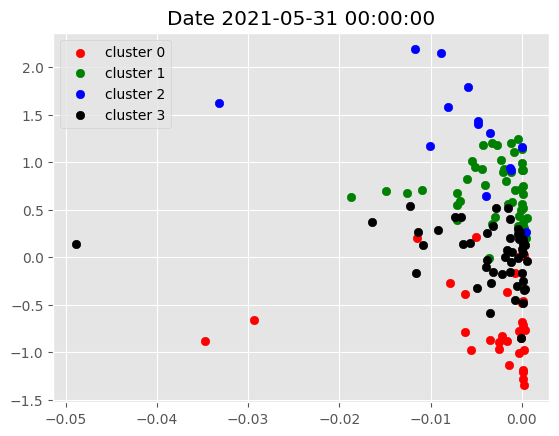

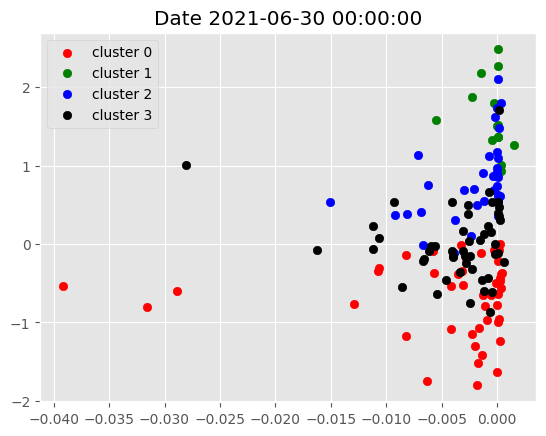

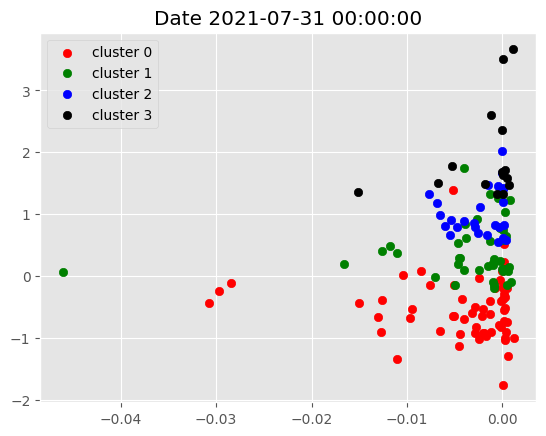

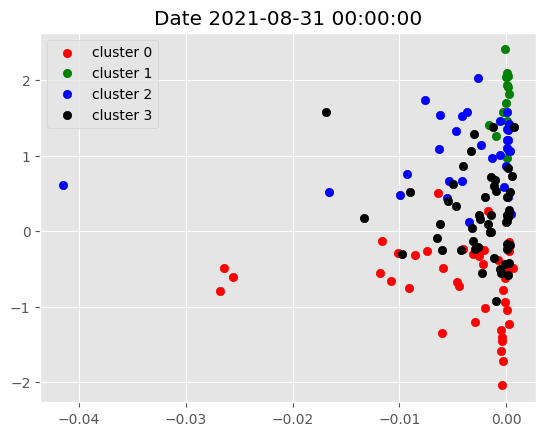

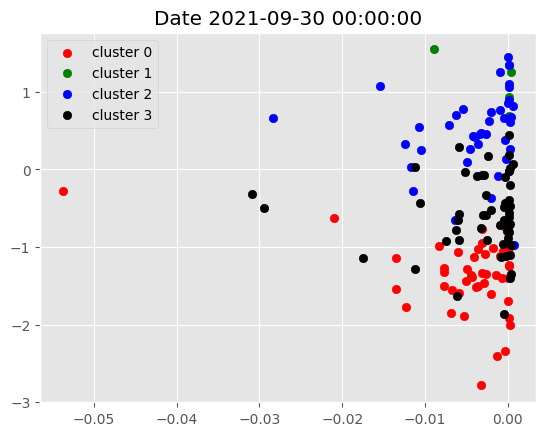

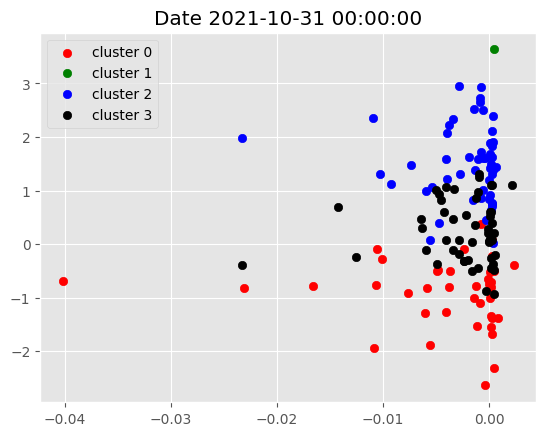

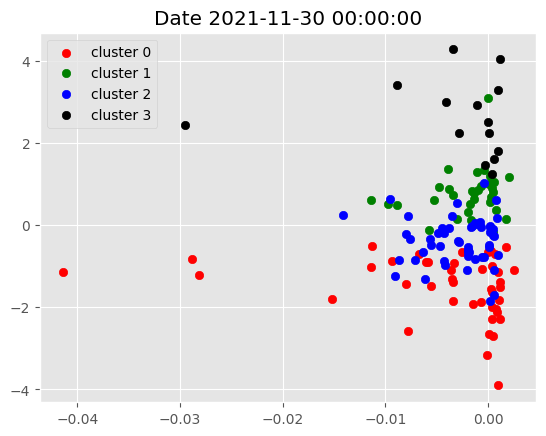

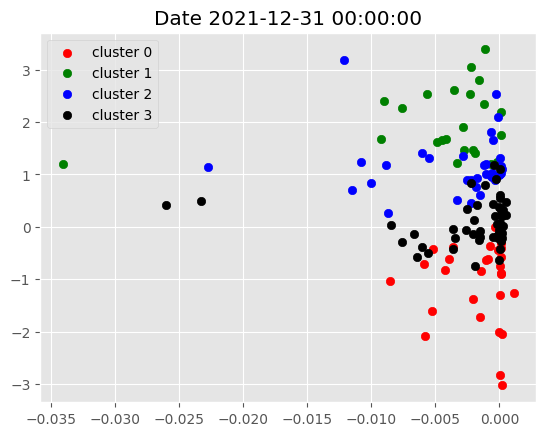

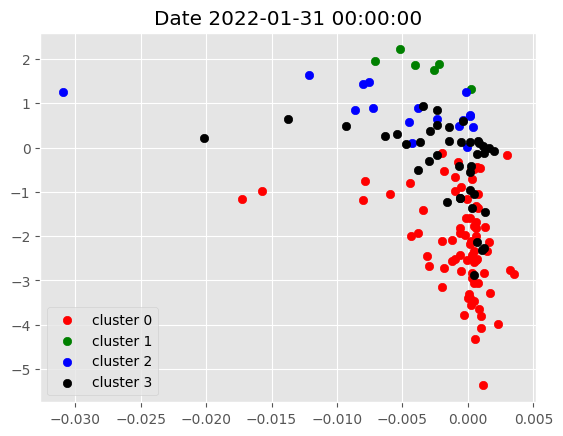

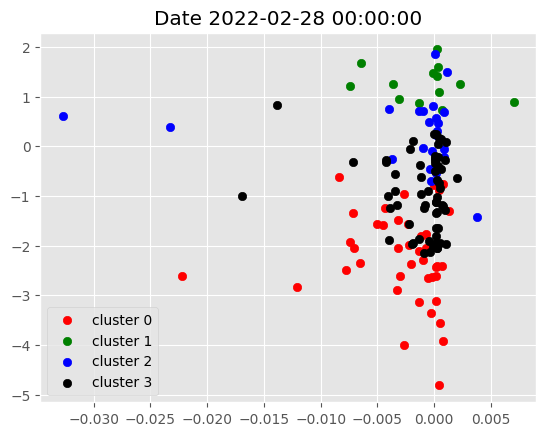

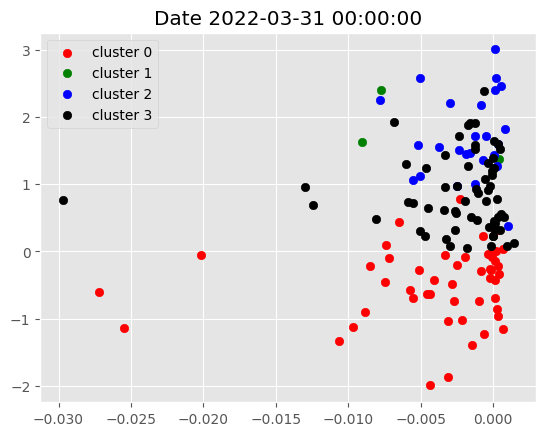

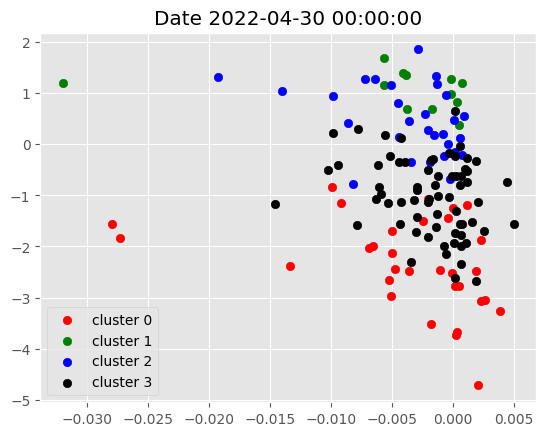

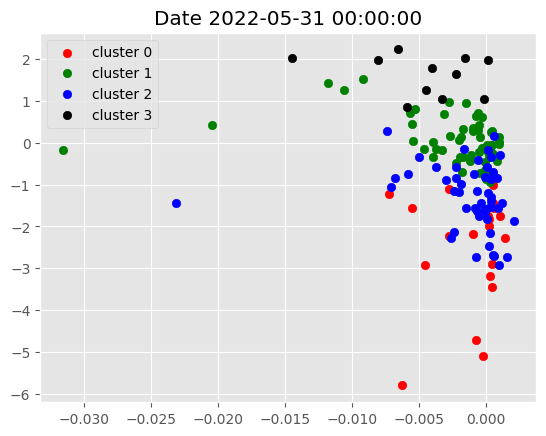

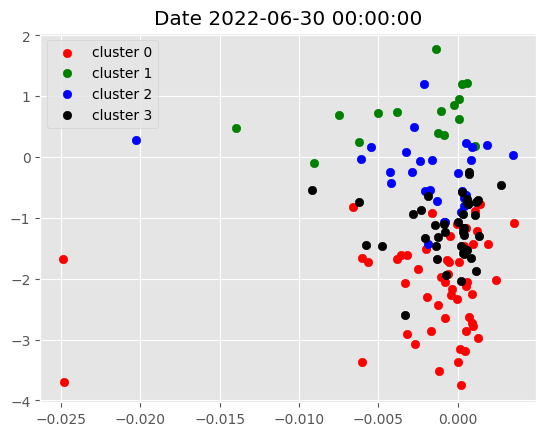

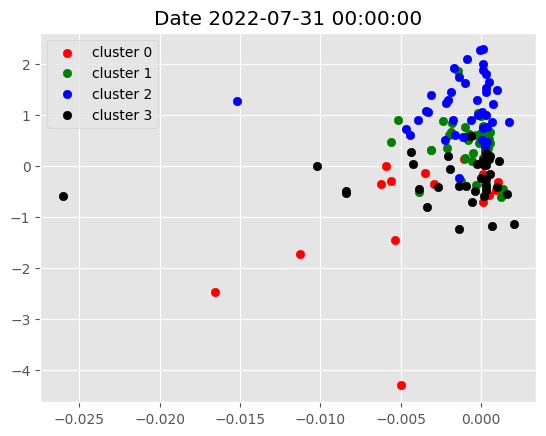

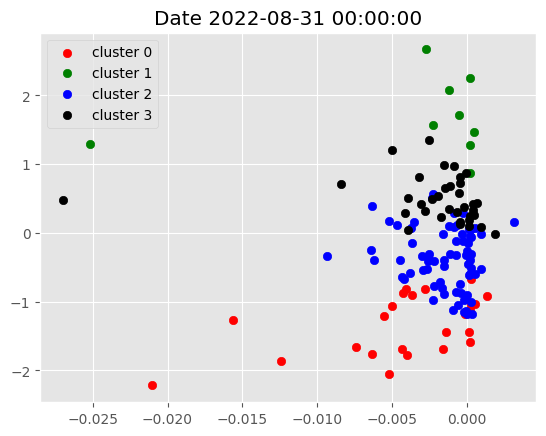

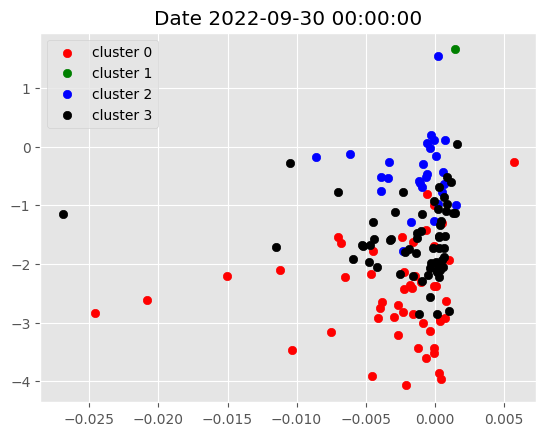

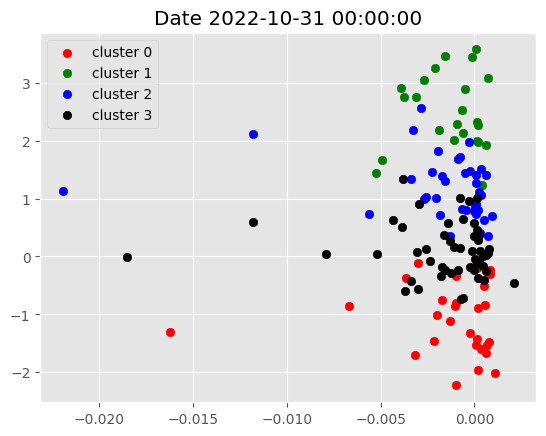

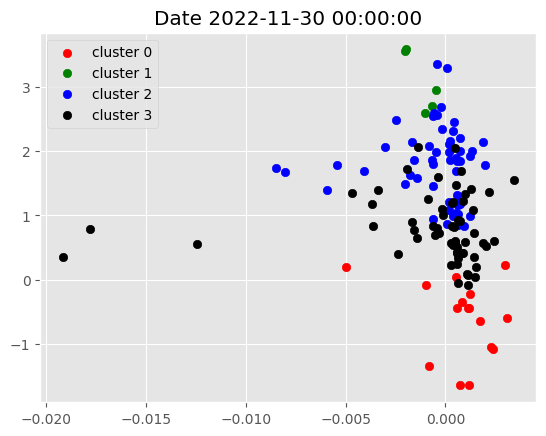

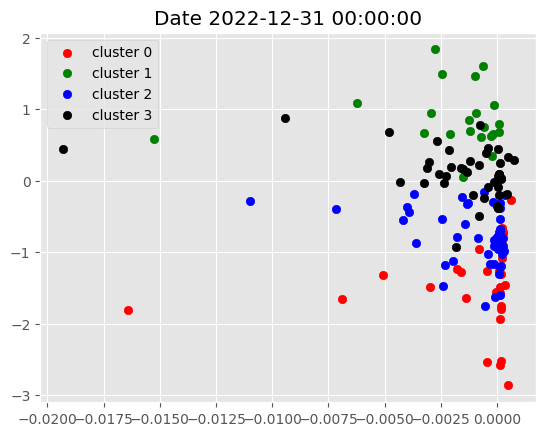

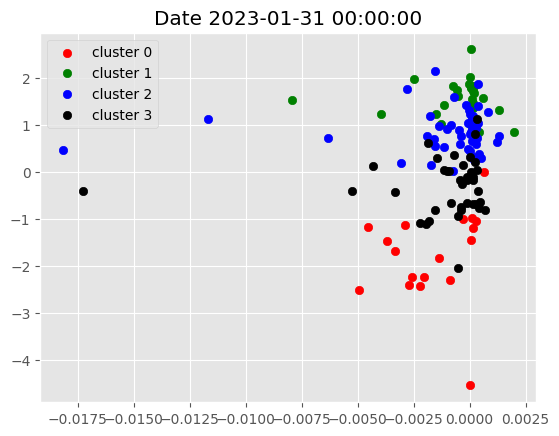

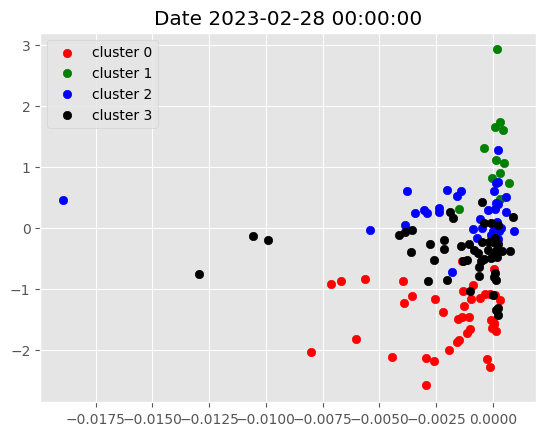

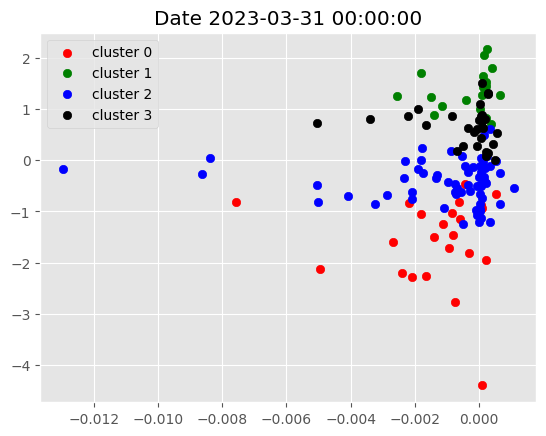

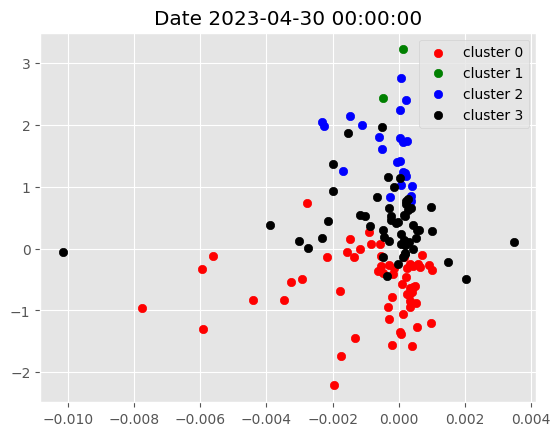

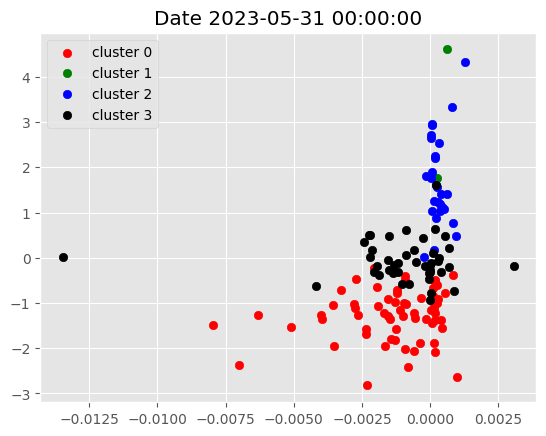

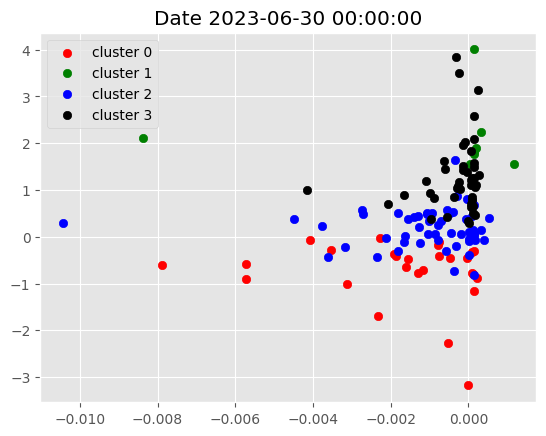

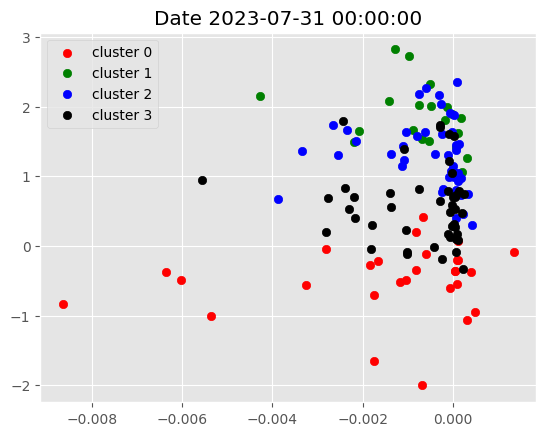

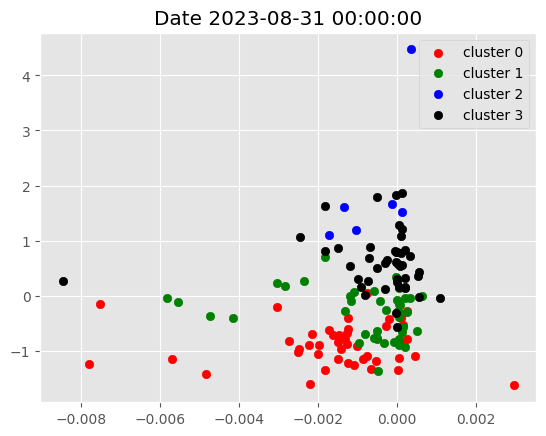

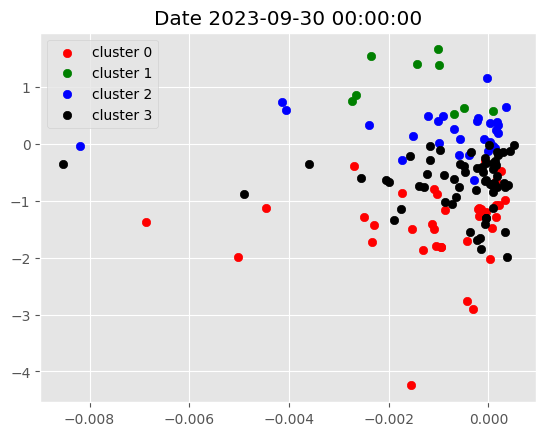

In [24]:
plt.style.use('ggplot')

for i in data.index.get_level_values('date').unique().tolist():
    
    g = data.xs(i, level=0)
    
    plt.title(f'Date {i}')
    
    plot_clusters(g)

In [25]:
data

garman_klass_vol        rsi    bb_low    bb_mid   bb_high  \
date       ticker                                                              
2017-10-31 AAPL           -0.001316  69.196736  3.589090  3.635955  3.682820   
           ABBV           -0.046862  55.247897  4.146029  4.192355  4.238681   
           ABT            -0.008097  53.844879  3.864398  3.887954  3.911510   
           ACN            -0.005890  69.365142  4.780248  4.819920  4.859593   
           ADBE            0.000067  70.089317  4.951759  5.089292  5.226825   
...                             ...        ...       ...       ...       ...   
2023-09-30 XYZ             0.000338  25.939817  3.799574  3.980555  4.161536   
           MRNA            0.000146  38.747314  4.582514  4.685332  4.788149   
           UBER            0.000441  45.005268  3.806654  3.862227  3.917801   
           CRWD            0.000144  51.534803  5.026187  5.103696  5.181204   
           DDOG            0.000314  37.040091  4.476874  4.560278  4.643681   

                        atr      macd  return_1m  return_2m  return_3m  \
date       ticker                                                        
2017-10-31 AAPL   -0.906642 -0.039275   0.096808   0.015250   0.044955   
           ABBV    0.375557  0.473816   0.022728   0.098590   0.091379   
           ABT    -1.040044  0.276133   0.021276   0.034308   0.034801   
           ACN    -0.986514  0.352342   0.064180   0.048454   0.037203   
           ADBE   -0.888269  0.612102   0.174152   0.062497   0.061392   
...                     ...       ...        ...        ...        ...   
2023-09-30 XYZ    -0.637443 -0.990293  -0.222723  -0.247423  -0.123607   
           MRNA   -0.529511 -0.376899  -0.132219  -0.086803  -0.068763   
           UBER   -0.746098 -0.133973  -0.062672  -0.053920   0.008422   
           CRWD   -0.744862  0.245950  -0.015641  -0.003656   0.029981   
           DDOG   -0.867969 -0.699392  -0.102716  -0.138786  -0.041732   

                   return_6m  return_9m  return_12m    Mkt-RF       SMB  \
date       ticker                                                         
2017-10-31 AAPL     0.028875   0.038941    0.035228  1.276518 -0.251058   
           ABBV     0.056495   0.047273    0.044026  0.505467  0.360797   
           ABT      0.038672   0.031320    0.029294  0.833399 -0.194859   
           ACN      0.028692   0.027398    0.018728  1.203790 -0.154550   
           ADBE     0.045993   0.049515    0.041515  1.109875 -0.318485   
...                      ...        ...         ...       ...       ...   
2023-09-30 XYZ     -0.068630  -0.036876   -0.016915  2.425948  1.930575   
           MRNA    -0.071952  -0.064976   -0.015431  1.153388  0.829705   
           UBER     0.057244   0.066838    0.043691  1.089340  1.123991   
           CRWD     0.026391   0.047942   -0.002216  0.596185 -0.982421   
           DDOG     0.029624   0.018352   -0.002098  0.598156  1.152212   

                        HML       RMW       CMA  cluster  
date       ticker                                         
2017-10-31 AAPL   -0.610539  0.680839  0.488806        2  
           ABBV   -0.030546  0.178882  0.188314        3  
           ABT    -0.528604  0.255533  0.985906        3  
           ACN    -0.339715  0.270245  0.196927        2  
           ADBE   -0.184536 -0.218400 -0.687454        2  
...                     ...       ...       ...      ...  
2023-09-30 XYZ    -0.378994 -1.637181  0.502943        0  
           MRNA   -1.184729  0.621376  1.032699        3  
           UBER   -0.230036 -1.532496 -0.493454        3  
           CRWD   -0.701008 -2.504568 -0.808184        2  
           DDOG   -0.670440 -0.681060 -0.694730        3  

[10084 rows x 19 columns]

## 7. For each month select assets based on the cluster and form a portfolio based on Efficient Frontier max sharpe ratio optimization

* First we will filter only stocks corresponding to the cluster we choose based on our hypothesis.

* Momentum is persistent and my idea would be that stocks clustered around RSI 70 centroid should continue to outperform in the following month - thus I would select stocks corresponding to cluster 3.


In [26]:
filtered_df = data[data['cluster']==3].copy()

filtered_df = filtered_df.reset_index(level=1)

filtered_df.index = filtered_df.index+pd.DateOffset(1)

filtered_df = filtered_df.reset_index().set_index(['date', 'ticker'])

dates = filtered_df.index.get_level_values('date').unique().tolist()

fixed_dates = {}

for d in dates:
    
    fixed_dates[d.strftime('%Y-%m-%d')] = filtered_df.xs(d, level=0).index.tolist()
    
fixed_dates

{'2017-11-01': ['ABBV',
  'ABT',
  'AZO',
  'BA',
  'BKNG',
  'BMY',
  'BRK-B',
  'C',
  'CCL',
  'COST',
  'CSCO',
  'CVX',
  'DD',
  'DG',
  'EA',
  'EBAY',
  'F',
  'FDX',
  'GM',
  'GS',
  'HAL',
  'HD',
  'HON',
  'HUM',
  'IBM',
  'JNJ',
  'KO',
  'LOW',
  'MDLZ',
  'MDT',
  'MO',
  'MS',
  'NFLX',
  'NKE',
  'NOC',
  'ORLY',
  'OXY',
  'PANW',
  'RTX',
  'SBUX',
  'SCHW',
  'TGT',
  'TMO',
  'UNP',
  'UPS',
  'USB',
  'WDC',
  'WYNN'],
 '2017-12-01': ['AAPL',
  'AMGN',
  'BIIB',
  'BMY',
  'CCL',
  'CL',
  'CMCSA',
  'CMG',
  'COP',
  'CRM',
  'DD',
  'EOG',
  'GD',
  'GILD',
  'GM',
  'GOOG',
  'GOOGL',
  'JNJ',
  'KO',
  'LLY',
  'MA',
  'MCK',
  'MDT',
  'META',
  'NVDA',
  'ORCL',
  'PANW',
  'PG',
  'PYPL',
  'STZ',
  'TGT',
  'TMO',
  'TXN',
  'ULTA',
  'V'],
 '2018-01-01': ['ABBV',
  'ADBE',
  'AMZN',
  'BIIB',
  'C',
  'CCL',
  'CHTR',
  'CMCSA',
  'CSX',
  'CVS',
  'DD',
  'DHR',
  'DIS',
  'EBAY',
  'ELV',
  'F',
  'GD',
  'GOOG',
  'GOOGL',
  'GS',
  'HON',
  'HUM',
 

### Define portfolio optimization function

* We will define a function which optimizes portfolio weights using PyPortfolioOpt package and EfficientFrontier optimizer to maximize the sharpe ratio.

* To optimize the weights of a given portfolio we would need to supply last 1 year prices to the function.

* Apply signle stock weight bounds constraint for diversification (minimum half of equaly weight and maximum 10% of portfolio).

In [27]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

def optimize_weights(prices, lower_bound=0):
    
    returns = expected_returns.mean_historical_return(prices=prices,
                                                      frequency=252)
    
    cov = risk_models.sample_cov(prices=prices,
                                 frequency=252)
    
    ef = EfficientFrontier(expected_returns=returns,
                           cov_matrix=cov,
                           weight_bounds=(lower_bound, .1),
                           solver='SCS')
    
    weights = ef.max_sharpe()
    
    return ef.clean_weights()


* Download Fresh Daily Prices Data only for short listed stocks.

In [28]:
stocks = data.index.get_level_values('ticker').unique().tolist()

new_df = yf.download(tickers=stocks,
                     start=data.index.get_level_values('date').unique()[0]-pd.DateOffset(months=12),
                     end=data.index.get_level_values('date').unique()[-1], auto_adjust=False)

new_df

[*********************100%***********************]  156 of 156 completed


Price        Adj Close                                                 \
Ticker            AAPL        ABBV        ABT         ACN        ADBE   
Date                                                                    
2016-10-31   26.060881   38.226257  33.321091  101.253769  107.510002   
2016-11-01   25.590340   38.685406  33.159744  101.166641  106.870003   
2016-11-02   25.613291   38.918415  32.862541  103.318199  105.889999   
2016-11-03   25.338753   38.301632  32.590813  101.872246  107.169998   
2016-11-04   25.110348   38.404419  33.193707  102.116135  106.199997   
...                ...         ...        ...         ...         ...   
2023-09-25  174.372040  142.726990  93.269547  306.312988  511.600006   
2023-09-26  170.292007  142.044052  92.082962  300.147888  506.299988   
2023-09-27  168.776840  141.324203  91.413147  303.790955  502.600006   
2023-09-28  169.034332  140.512054  93.891533  290.639343  504.670013   
2023-09-29  169.549271  137.567963  92.676254  296.765808  509.899994   

Price                                                                  ...  \
Ticker             ADP        ADSK        AIG        AMAT         AMD  ...   
Date                                                                   ...   
2016-10-31   71.959038   72.279999  49.121162   26.281973    7.230000  ...   
2016-11-01   71.843338   70.099998  48.309113   26.119293    7.090000  ...   
2016-11-02   74.372551   68.680000  48.205620   25.839123    6.760000  ...   
2016-11-03   73.835320   67.610001  46.294910   25.549910    6.700000  ...   
2016-11-04   73.628662   69.440002  45.681896   25.504721    6.560000  ...   
...                ...         ...        ...         ...         ...  ...   
2023-09-25  229.862701  205.669998  59.545383  134.163177   97.379997  ...   
2023-09-26  227.200378  201.660004  58.711578  131.697784   95.959999  ...   
2023-09-27  232.362274  202.279999  58.471977  132.660370   98.070000  ...   
2023-09-28  233.013489  207.889999  58.730743  135.764236  102.760002  ...   
2023-09-29  230.399017  206.910004  58.079033  135.990158  102.820000  ...   

Price        Volume                                                           \
Ticker          VLO     VRTX        VZ     WDAY      WDC       WFC       WMT   
Date                                                                           
2016-10-31  4969500  1928200  12459400  1147300  4449514  20115900  19167000   
2016-11-01  7816800  2458200  13229400  1091400  5055315  20020200  26515800   
2016-11-02  7317600  2580400  16488200  1127800  5578033  19566600  22935900   
2016-11-03  3855900  2371000  12605100   633300  4223810  14982700  20411700   
2016-11-04  3729900  1902100  14410200   892600  3579509  27391600  21786300   
...             ...      ...       ...      ...      ...       ...       ...   
2023-09-25  3241900   698100  17616900   894200  3553446  10624000  10459500   
2023-09-26  4936800   633600  18841600  1217300  4724565  15219400  14435700   
2023-09-27  3644000   860600  22083500  2338100  3370739  11815500  15711000   
2023-09-28  3587300   578900  18772100  9196300  4342086  12454600  11617200   
2023-09-29  4302200   896800  19787600  4066600  3323376  13124500  18842400   

Price                                    
Ticker         WYNN       XOM       XYZ  
Date                                     
2016-10-31  1341600  16663800   2960600  
2016-11-01  3722300  13050600   8190900  
2016-11-02  2542400  11226100  19503200  
2016-11-03  9050400   8836500   7371500  
2016-11-04  3223800  13877100  13462800  
...             ...       ...       ...  
2023-09-25  1387800  11316000   8841300  
2023-09-26  1454000  11805400  10168200  
2023-09-27  2050000  23976200  11656100  
2023-09-28  1290400  16808100  16585100  
2023-09-29  1326800  18813600  11965300  

[1740 rows x 936 columns]

* Calculate daily returns for each stock which could land up in our portfolio.

* Then loop over each month start, select the stocks for the month and calculate their weights for the next month.

* If the maximum sharpe ratio optimization fails for a given month, apply equally-weighted weights.

* Calculated each day portfolio return.

In [52]:
returns_dataframe = np.log(new_df['Adj Close']).diff()

portfolio_df = pd.DataFrame()

for start_date in fixed_dates.keys():
    try:
        end_date = (pd.to_datetime(start_date)+pd.offsets.MonthEnd(0)).strftime('%Y-%m-%d')

        cols = fixed_dates[start_date]

        optimization_start_date = (pd.to_datetime(start_date)-pd.DateOffset(months=12)).strftime('%Y-%m-%d')

        optimization_end_date = (pd.to_datetime(start_date)-pd.DateOffset(days=1)).strftime('%Y-%m-%d')
        
        optimization_df = new_df[optimization_start_date:optimization_end_date]['Adj Close'][cols]
        
        success = False
        try:
            weights = optimize_weights(prices=optimization_df,
                                   lower_bound=round(1/(len(optimization_df.columns)*2),3))

            weights = pd.DataFrame(weights, index=pd.Series(0))
            
            success = True
        except:
            print(f'Max Sharpe Optimization failed for {start_date}, Continuing with Equal-Weights')
        
        if success==False:
            weights = pd.DataFrame([1/len(optimization_df.columns) for i in range(len(optimization_df.columns))],
                                     index=optimization_df.columns.tolist(),
                                     columns=pd.Series(0)).T
        
        # temp_df = returns_dataframe[start_date:end_date]

        # temp_df = temp_df.stack().to_frame('return').reset_index(level=0)\
        #            .merge(weights.stack().to_frame('weight').reset_index(level=0, drop=True),
        #                   left_index=True,
        #                   right_index=True)\
        #            .reset_index().set_index(['Date', 'index']).unstack().stack()

        # temp_df.index.names = ['date', 'ticker']

        # temp_df['weighted_return'] = temp_df['return']*temp_df['weight']

        # temp_df = temp_df.groupby(level=0)['weighted_return'].sum().to_frame('Strategy Return')

        # portfolio_df = pd.concat([portfolio_df, temp_df], axis=0)
    
        temp_df = returns_dataframe[start_date:end_date]

        # Convert to long format: Date, Ticker, Return
        temp_df = temp_df.stack().reset_index()
        temp_df.columns = ['Date', 'Ticker', 'Return']

        # Prepare weights (make sure it's a Series with tickers as index)
        weights_s = weights.T.squeeze()
        weights_s.index.name = 'Ticker'

        # Merge returns with weights
        temp_df = temp_df.merge(weights_s.rename('Weight'), on='Ticker', how='left')

        # Calculate weighted returns
        temp_df['Weighted_Return'] = temp_df['Return'] * temp_df['Weight']

        # Aggregate to get portfolio return for that month
        temp_df = temp_df.groupby('Date')['Weighted_Return'].sum().to_frame('Strategy Return')

        # Add to the overall portfolio DataFrame
        portfolio_df = pd.concat([portfolio_df, temp_df])

    except Exception as e:
        print(e)

portfolio_df = portfolio_df.drop_duplicates()

portfolio_df

,Strategy Return
Date,
2017-11-01,0.001405
2017-11-02,-0.000161
2017-11-03,0.003134
2017-11-06,-0.000712
2017-11-07,-0.000545
...,...
2023-09-25,0.005553
2023-09-26,-0.014819
2023-09-27,0.006184


In [ ]:
print(portfolio_df.columns)
print(spy_ret.columns)

Index(['Strategy Return'], dtype='object')
Index(['SPY Buy&Hold'], dtype='object', name='Price')


In [ ]:
spy_ret.columns = spy_ret.columns.get_level_values(0)


In [49]:
print(spy_ret.columns)


Index(['SPY Buy&Hold'], dtype='object', name='Price')


## 8. Visualize Portfolio returns and compare to SP500 returns.

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import datetime as dt

# Download SPY data
spy = yf.download('SPY', start='2015-01-01', end=dt.date.today(), auto_adjust=False)

# Compute log returns
spy_ret = np.log(spy['Adj Close']).diff().dropna()

# Ensure it's a DataFrame with a clean column name
spy_ret = pd.DataFrame(spy_ret)
spy_ret.columns = ['SPY Buy&Hold']

# Merge with your strategy DataFrame
portfolio_df = portfolio_df.merge(spy_ret, left_index=True, right_index=True)

portfolio_df.head()


[*********************100%***********************]  1 of 1 completed


,Strategy Return,SPY Buy&Hold
Date,,
2017-11-01,0.001405,0.001321
2017-11-02,-0.000161,0.000388
2017-11-03,0.003134,0.003333
2017-11-06,-0.000712,0.001547
2017-11-07,-0.000545,-0.000696


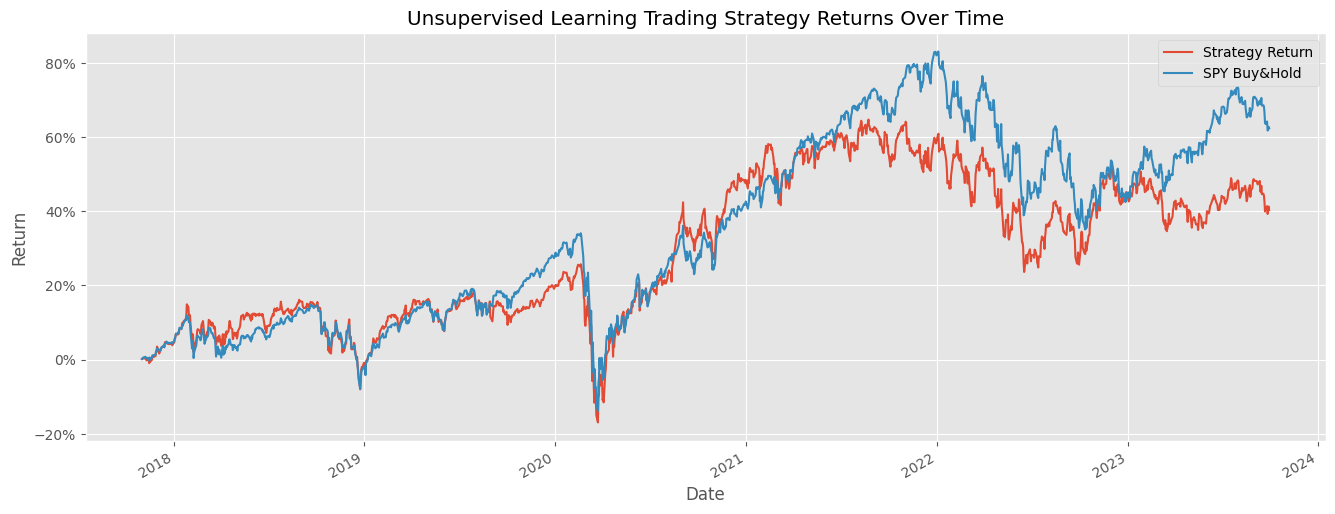

In [375]:
import matplotlib.ticker as mtick

plt.style.use('ggplot')

portfolio_cumulative_return = np.exp(np.log1p(portfolio_df).cumsum())-1

portfolio_cumulative_return[:'2023-09-29'].plot(figsize=(16,6))

plt.title('Unsupervised Learning Trading Strategy Returns Over Time')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()
